# Remove Duplicate Images

This notebook scans a source folder for images, detects pixel-level duplicates using perceptual hashing, and copies only unique images to a new output folder.

**Rules:**
- The original source folder is **never modified**
- When duplicates are found, the **first encountered** image is kept
- All unique images are copied to the output folder, preserving subfolder structure

## 1. Configuration — Set Your Paths Here

In [1]:
# ─── CONFIGURE THESE TWO PATHS ───────────────────────────────────────────────

SOURCE_FOLDER = "/cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-14-36/frames/2024-08-20_17-14-36_CUT_stillDUPLICATE"   # e.g. "/data/SOLAQUA/raw_processed"
OUTPUT_FOLDER = "/cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-14-36/frames/2024-08-20_17-14-36"   # e.g. "/data/SOLAQUA/deduplicated"

# ─── OPTIONAL SETTINGS ───────────────────────────────────────────────────────

# Supported image extensions (lowercase)
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".tif", ".webp"}

# Hash method: 'md5'  = exact pixel-level duplicates only (fastest)
#              'phash' = perceptual hash, catches near-identical images too
#                        (requires 'imagehash' library — pip install imagehash)
HASH_METHOD = "md5"   # Change to 'phash' for near-duplicate detection

# Only used when HASH_METHOD = 'phash'.
# Max hamming distance to consider two images duplicates (0 = identical, 10 = very similar)
PHASH_THRESHOLD = 5

print("✅ Configuration loaded.")
print(f"   Source : {SOURCE_FOLDER}")
print(f"   Output : {OUTPUT_FOLDER}")
print(f"   Method : {HASH_METHOD}")

✅ Configuration loaded.
   Source : /cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-14-36/frames/2024-08-20_17-14-36_CUT_stillDUPLICATE
   Output : /cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-14-36/frames/2024-08-20_17-14-36
   Method : md5


ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/cluster/home/henrban/aquaculture-perception/.venv/lib64/python3.9/site-packages/traitlets/traitlets.py", line 632, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/cluster/home/henrban/aquaculture-perception/.venv/lib64/python3.9/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/cluster/home/henrban/aquaculture-perception/.venv/lib64/python3.9/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/cluster/home/henrban/aquaculture-perception/.venv/lib64/python3.9/site-packages/traitlets/traitlets.py", line 687, in __get__
    return t.cast(G, self.get(obj, cls))  # the G should encode the Optional
  File "/cluster/home/henrban/aquaculture-percepti

## 2. Install / Import Dependencies

In [2]:
import sys
import os
import hashlib
import shutil
from pathlib import Path
from collections import defaultdict

from PIL import Image

if HASH_METHOD == "phash":
    try:
        import imagehash
    except ImportError:
        print("Installing imagehash ...")
        os.system(f"{sys.executable} -m pip install imagehash -q")
        import imagehash

print("✅ All imports successful.")

✅ All imports successful.


## 3. Helper Functions

In [3]:
def get_md5_hash(filepath: Path) -> str:
    """Return MD5 hash of raw file bytes — exact duplicate detection."""
    h = hashlib.md5()
    with open(filepath, "rb") as f:
        for chunk in iter(lambda: f.read(65536), b""):
            h.update(chunk)
    return h.hexdigest()


def get_pixel_md5_hash(filepath: Path) -> str:
    """Return MD5 hash of decoded pixel data — catches same-content images
    saved with different compression or metadata."""
    with Image.open(filepath) as img:
        # Convert to RGB to normalise palette/RGBA differences
        pixel_bytes = img.convert("RGB").tobytes()
    return hashlib.md5(pixel_bytes).hexdigest()


def get_phash(filepath: Path) -> "imagehash.ImageHash":
    """Return perceptual hash — robust to minor edits, compression artefacts."""
    with Image.open(filepath) as img:
        return imagehash.phash(img)


def collect_images(source: Path, extensions: set) -> list[Path]:
    """Recursively collect all image files under *source*, sorted by path
    so that the first encountered (alphabetically) is always kept."""
    images = [
        p for p in sorted(source.rglob("*"))
        if p.is_file() and p.suffix.lower() in extensions
    ]
    return images


print("✅ Helper functions defined.")

✅ Helper functions defined.


## 4. Scan & Detect Duplicates

In [4]:
source_path = Path(SOURCE_FOLDER)
output_path = Path(OUTPUT_FOLDER)

assert source_path.exists(), f"Source folder not found: {source_path}"

print(f"🔍 Scanning: {source_path}")
all_images = collect_images(source_path, IMAGE_EXTENSIONS)
print(f"   Found {len(all_images)} image(s) in total.\n")

# ── Build hash → [list of paths] mapping ──────────────────────────────────────
seen_hashes: dict = {}          # hash → first (kept) path
kept:        list[Path] = []
duplicates:  list[tuple[Path, Path]] = []  # (duplicate, original)
errors:      list[tuple[Path, str]] = []

# For phash we need a list of (hash, path) to do threshold comparison
phash_registry: list[tuple] = []  # [(imagehash, path), ...]

for idx, img_path in enumerate(all_images, 1):
    print(f"  [{idx:>5}/{len(all_images)}] {img_path.name}", end="  ")

    try:
        if HASH_METHOD == "md5":
            h = get_pixel_md5_hash(img_path)
            if h in seen_hashes:
                print(f"→ DUPLICATE of {seen_hashes[h].name}")
                duplicates.append((img_path, seen_hashes[h]))
            else:
                seen_hashes[h] = img_path
                kept.append(img_path)
                print("→ unique ✓")

        elif HASH_METHOD == "phash":
            h = get_phash(img_path)
            match = None
            for existing_hash, existing_path in phash_registry:
                if (h - existing_hash) <= PHASH_THRESHOLD:
                    match = existing_path
                    break
            if match:
                print(f"→ DUPLICATE of {match.name}")
                duplicates.append((img_path, match))
            else:
                phash_registry.append((h, img_path))
                kept.append(img_path)
                print("→ unique ✓")

    except Exception as exc:
        print(f"→ ERROR: {exc}")
        errors.append((img_path, str(exc)))

print(f"\n{'─'*60}")
print(f"  Total images  : {len(all_images)}")
print(f"  Unique (keep) : {len(kept)}")
print(f"  Duplicates    : {len(duplicates)}")
print(f"  Errors        : {len(errors)}")
print(f"{'─'*60}")

🔍 Scanning: /cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-14-36/frames/2024-08-20_17-14-36_CUT_stillDUPLICATE
   Found 1086 image(s) in total.

  [    1/1086] 1724166879127906200.jpg  → unique ✓
  [    2/1086] 1724166879173609200.jpg  → unique ✓
  [    3/1086] 1724166879221280700.jpg  → unique ✓
  [    4/1086] 1724166879253245100.jpg  → unique ✓
  [    5/1086] 1724166879296363900.jpg  → unique ✓
  [    6/1086] 1724166879341902500.jpg  → DUPLICATE of 1724166879296363900.jpg
  [    7/1086] 1724166879371265700.jpg  → unique ✓
  [    8/1086] 1724166879416051900.jpg  → unique ✓
  [    9/1086] 1724166879463067000.jpg  → unique ✓
  [   10/1086] 1724166879493221800.jpg  → unique ✓
  [   11/1086] 1724166879543115800.jpg  → unique ✓
  [   12/1086] 1724166879570146100.jpg  → DUPLICATE of 1724166879543115800.jpg
  [   13/1086] 1724166879615983000.jpg  → unique ✓
  [   14/1086] 1724166879661870400.jpg  → unique ✓
  [   15/1086] 1724166879696102200.jpg  → uniq

## 5. Preview Duplicate Groups

In [5]:
if not duplicates:
    print("🎉 No duplicates found — all images are unique!")
else:
    print(f"Found {len(duplicates)} duplicate image(s):\n")
    for dup, original in duplicates:
        # Show paths relative to source folder for readability
        print(f"  KEEP   → {original.relative_to(source_path)}")
        print(f"  REMOVE → {dup.relative_to(source_path)}")
        print()

Found 252 duplicate image(s):

  KEEP   → 1724166879296363900.jpg
  REMOVE → 1724166879341902500.jpg

  KEEP   → 1724166879543115800.jpg
  REMOVE → 1724166879570146100.jpg

  KEEP   → 1724166879696102200.jpg
  REMOVE → 1724166879737914900.jpg

  KEEP   → 1724166879893481900.jpg
  REMOVE → 1724166879936455600.jpg

  KEEP   → 1724166880087819000.jpg
  REMOVE → 1724166880133231000.jpg

  KEEP   → 1724166880300417200.jpg
  REMOVE → 1724166880330942100.jpg

  KEEP   → 1724166880501013600.jpg
  REMOVE → 1724166880532944300.jpg

  KEEP   → 1724166880577447900.jpg
  REMOVE → 1724166880608185800.jpg

  KEEP   → 1724166880697949900.jpg
  REMOVE → 1724166880728546100.jpg

  KEEP   → 1724166880896334700.jpg
  REMOVE → 1724166880944243400.jpg

  KEEP   → 1724166881138122600.jpg
  REMOVE → 1724166881169516200.jpg

  KEEP   → 1724166881291787700.jpg
  REMOVE → 1724166881339873700.jpg

  KEEP   → 1724166881489895200.jpg
  REMOVE → 1724166881534865300.jpg

  KEEP   → 1724166881700558700.jpg
  REMOVE → 

## 6. Visual Side-by-Side Preview of Duplicates (optional)

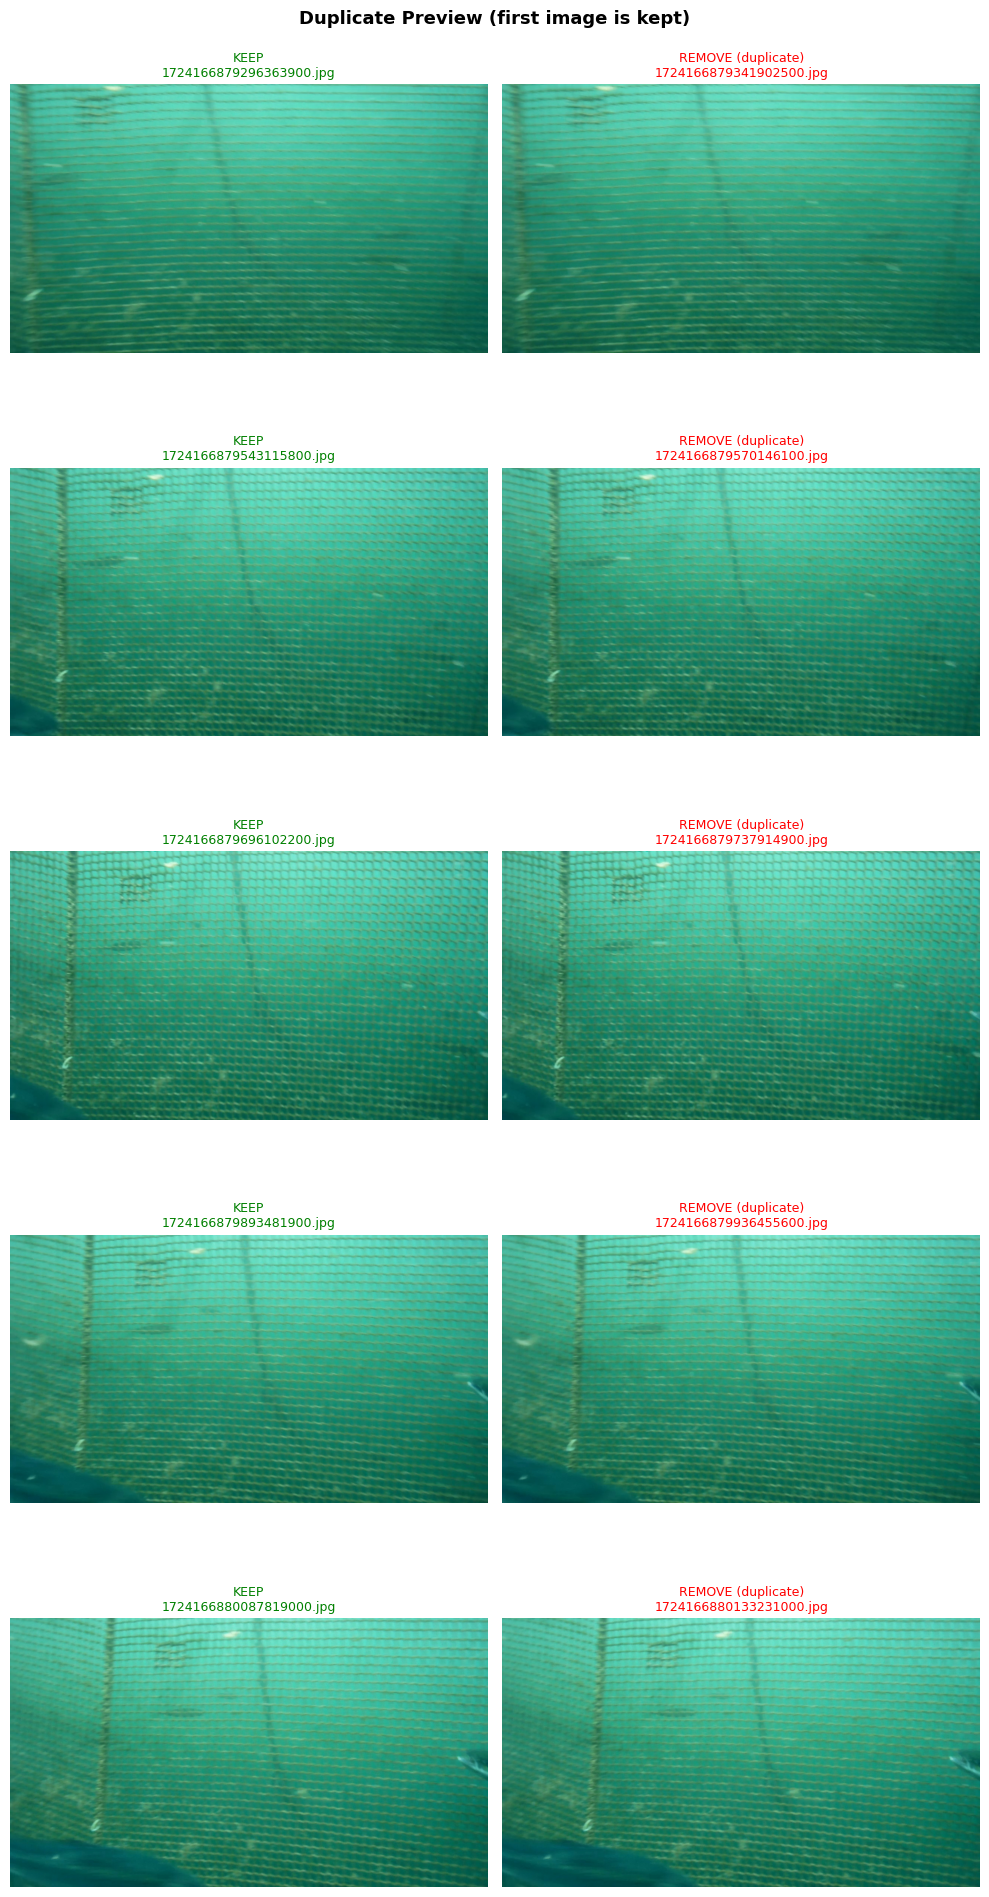

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

MAX_PREVIEW = 5  # Maximum duplicate pairs to display

if duplicates:
    preview_pairs = duplicates[:MAX_PREVIEW]
    fig, axes = plt.subplots(len(preview_pairs), 2,
                             figsize=(10, 4 * len(preview_pairs)))
    if len(preview_pairs) == 1:
        axes = [axes]  # Ensure iterable when only 1 pair

    for ax_row, (dup, original) in zip(axes, preview_pairs):
        for ax, path, label in [
            (ax_row[0], original, "KEEP"),
            (ax_row[1], dup,      "REMOVE (duplicate)"),
        ]:
            img = mpimg.imread(path)
            ax.imshow(img)
            ax.set_title(f"{label}\n{path.name}", fontsize=9, color="green" if label == "KEEP" else "red")
            ax.axis("off")

    plt.suptitle("Duplicate Preview (first image is kept)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("No duplicates to preview.")

## 7. Copy Unique Images to Output Folder

In [7]:
# Safety check — confirm before writing
print(f"About to copy {len(kept)} unique image(s) to:")
print(f"  {output_path}\n")
print("Subfolder structure from the source folder will be preserved.")

confirm = input("Proceed? [y/N]: ").strip().lower()
if confirm != "y":
    print("Cancelled — no files were written.")
else:
    output_path.mkdir(parents=True, exist_ok=True)
    copied = 0
    copy_errors = []

    for img_path in kept:
        # Reproduce the same subfolder structure under output_path
        relative = img_path.relative_to(source_path)
        dest = output_path / relative
        dest.parent.mkdir(parents=True, exist_ok=True)

        try:
            shutil.copy2(img_path, dest)   # copy2 preserves metadata timestamps
            copied += 1
        except Exception as exc:
            copy_errors.append((img_path, str(exc)))
            print(f"  ⚠️  Failed to copy {img_path.name}: {exc}")

    print(f"\n✅ Done!")
    print(f"   Copied  : {copied} image(s)")
    print(f"   Skipped : {len(duplicates)} duplicate(s)")
    if copy_errors:
        print(f"   Errors  : {len(copy_errors)}")
    print(f"   Output  : {output_path}")

About to copy 834 unique image(s) to:
  /cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-14-36/frames/2024-08-20_17-14-36

Subfolder structure from the source folder will be preserved.

✅ Done!
   Copied  : 834 image(s)
   Skipped : 252 duplicate(s)
   Output  : /cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-14-36/frames/2024-08-20_17-14-36


## 8. Save a Duplicate Report (CSV)

In [ ]:
import csv
from datetime import datetime

report_path = output_path / f"duplicate_report_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"

with open(report_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["action", "image_path", "duplicate_of"])

    for img_path in kept:
        writer.writerow(["kept", str(img_path), ""])

    for dup, original in duplicates:
        writer.writerow(["removed", str(dup), str(original)])

    for err_path, err_msg in errors:
        writer.writerow([f"error: {err_msg}", str(err_path), ""])

print(f"📄 Report saved to: {report_path}")

---
## 9. Clean Annotation File — Remove Rows for Missing Frame IDs

After deduplication the output image folder may be missing some frame IDs that still exist in the annotation CSV.  
This cell:
1. Reads the annotation CSV (no header row assumed, first column = frame ID)
2. Builds the set of frame IDs present in the **output** image folder
3. Keeps only annotation rows whose frame ID has a matching image
4. Writes the cleaned annotations to a new file — the original is never modified

In [8]:
# ─── CONFIGURE ANNOTATION PATHS ──────────────────────────────────────────────

ANNOTATION_FILE   = "/cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-14-36/gt/gt.txt"   # original annotation file
CLEANED_ANNO_FILE = "/cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-14-36/gt/gt_clean.txt"  # output (never overwrites original)

# Column index (0-based) that holds the frame ID in the CSV
FRAME_ID_COLUMN = 0

# Does the annotation CSV have a header row?
HAS_HEADER = False

# Which image folder to use as the source of truth for surviving frame IDs.
# Defaults to OUTPUT_FOLDER set in Cell 1 (the deduplicated folder).
# Change to SOURCE_FOLDER if you want to validate against the original folder instead.
REFERENCE_IMAGE_FOLDER = OUTPUT_FOLDER

print("✅ Annotation config loaded.")
print(f"   Annotation in  : {ANNOTATION_FILE}")
print(f"   Annotation out : {CLEANED_ANNO_FILE}")
print(f"   Reference imgs : {REFERENCE_IMAGE_FOLDER}")

✅ Annotation config loaded.
   Annotation in  : /cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-14-36/gt/gt.txt
   Annotation out : /cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-14-36/gt/gt_clean.txt
   Reference imgs : /cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-14-36/frames/2024-08-20_17-14-36


In [9]:
import csv
from pathlib import Path

anno_path   = Path(ANNOTATION_FILE)
cleaned_path = Path(CLEANED_ANNO_FILE)
ref_path    = Path(REFERENCE_IMAGE_FOLDER)

assert anno_path.exists(),  f"Annotation file not found: {anno_path}"
assert ref_path.exists(),   f"Reference image folder not found: {ref_path}"

# ── Step 1: collect frame IDs present in the reference image folder ───────────
surviving_frame_ids: set[str] = set()
for p in ref_path.rglob("*"):
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS:
        surviving_frame_ids.add(p.stem)   # filename without extension = frame ID

print(f"🖼️  Frame IDs found in reference folder : {len(surviving_frame_ids)}")

# ── Step 2: filter the annotation file ───────────────────────────────────────
kept_rows    = []
removed_rows = []
header_row   = None

with open(anno_path, "r", newline="", encoding="utf-8") as f:
    reader = csv.reader(f)

    if HAS_HEADER:
        header_row = next(reader)

    for row in reader:
        if not row:          # skip blank lines
            continue
        frame_id = row[FRAME_ID_COLUMN].strip()
        if frame_id in surviving_frame_ids:
            kept_rows.append(row)
        else:
            removed_rows.append(row)

total_rows = len(kept_rows) + len(removed_rows)
print(f"📋 Total annotation rows  : {total_rows}")
print(f"   Rows kept             : {len(kept_rows)}")
print(f"   Rows removed          : {len(removed_rows)} (frame ID not in image folder)")

# ── Step 3: write the cleaned annotation file ─────────────────────────────────
cleaned_path.parent.mkdir(parents=True, exist_ok=True)

with open(cleaned_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    if HAS_HEADER and header_row is not None:
        writer.writerow(header_row)
    writer.writerows(kept_rows)

print(f"\n✅ Cleaned annotation file saved to:")
print(f"   {cleaned_path}")

🖼️  Frame IDs found in reference folder : 834
📋 Total annotation rows  : 1181
   Rows kept             : 899
   Rows removed          : 282 (frame ID not in image folder)

✅ Cleaned annotation file saved to:
   /cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-14-36/gt/gt_clean.txt


In [10]:
# ── Optional: preview the removed rows ───────────────────────────────────────
MAX_SHOW = 20

if not removed_rows:
    print("🎉 No annotation rows were removed — every frame ID has a matching image.")
else:
    print(f"First {min(MAX_SHOW, len(removed_rows))} removed annotation row(s):\n")
    for row in removed_rows[:MAX_SHOW]:
        frame_id = row[FRAME_ID_COLUMN]
        print(f"  frame_id={frame_id}  →  no matching image found, row removed")
    if len(removed_rows) > MAX_SHOW:
        print(f"  ... and {len(removed_rows) - MAX_SHOW} more (see cleaned CSV for full list)")

First 20 removed annotation row(s):

  frame_id=1724166879570146100  →  no matching image found, row removed
  frame_id=1724166879737914900  →  no matching image found, row removed
  frame_id=1724166879936455600  →  no matching image found, row removed
  frame_id=1724166879936455600  →  no matching image found, row removed
  frame_id=1724166880133231000  →  no matching image found, row removed
  frame_id=1724166880133231000  →  no matching image found, row removed
  frame_id=1724166880330942100  →  no matching image found, row removed
  frame_id=1724166880330942100  →  no matching image found, row removed
  frame_id=1724166880532944300  →  no matching image found, row removed
  frame_id=1724166880532944300  →  no matching image found, row removed
  frame_id=1724166880532944300  →  no matching image found, row removed
  frame_id=1724166880608185800  →  no matching image found, row removed
  frame_id=1724166880608185800  →  no matching image found, row removed
  frame_id=1724166880608185

---
## 10. Cut Trailing Digits from Image Filenames & Annotation Frame IDs

Timestamp-based filenames like `1724169343107751600.jpg` carry more digits than needed and can cause rounding issues downstream.  
This section:
1. Copies images from a source folder to a new output folder, renaming each file by removing N trailing digits from the stem
2. Rewrites the annotation file so every frame ID in column 0 is shortened by the same N digits
3. Detects ID collisions **before** writing anything, so you never silently overwrite files

**Neither the source image folder nor the original annotation file is modified.**

In [ ]:
# ─── CONFIGURE ───────────────────────────────────────────────────────────────

# Source folder containing the images to rename (defaults to OUTPUT_FOLDER from Section 7)
CUT_SOURCE_FOLDER = OUTPUT_FOLDER          # or set a custom path string

# Destination folder for the renamed images (must not already exist)
CUT_OUTPUT_FOLDER = OUTPUT_FOLDER + '_cut'

# Annotation file whose frame IDs should be shortened (defaults to CLEANED_ANNO_FILE from Section 9)
CUT_ANNO_INPUT    = CLEANED_ANNO_FILE      # or set a custom path string

# Where to write the digit-cut annotation file
CUT_ANNO_OUTPUT   = CLEANED_ANNO_FILE.replace('.txt', '_cut.txt').replace('.csv', '_cut.csv')

# Number of trailing digits to remove from every numeric filename stem
DIGITS_TO_CUT = 5

# Column index (0-based) of the frame ID in the annotation file
ANNO_FRAME_ID_COL = 0

print('\u2705 Digit-cut config loaded.')
print(f'   Image source  : {CUT_SOURCE_FOLDER}')
print(f'   Image output  : {CUT_OUTPUT_FOLDER}')
print(f'   Anno input    : {CUT_ANNO_INPUT}')
print(f'   Anno output   : {CUT_ANNO_OUTPUT}')
print(f'   Digits to cut : {DIGITS_TO_CUT}')

In [ ]:
import shutil, csv
from pathlib import Path

# ── Helper ────────────────────────────────────────────────────────────────────
def cut_id(stem: str, n: int) -> str:
    """Remove n trailing digits from a purely numeric filename stem."""
    if not stem.isdigit():
        raise ValueError(f"Stem is not numeric: '{stem}'")
    if len(stem) <= n:
        raise ValueError(f"Cannot cut {n} digits from '{stem}' (only {len(stem)} digits)")
    return stem[:-n]


# ── Part A: rename and copy images ────────────────────────────────────────────
cut_src = Path(CUT_SOURCE_FOLDER)
cut_out = Path(CUT_OUTPUT_FOLDER)

assert cut_src.exists(), f'Source folder not found: {cut_src}'

if cut_out.exists():
    raise FileExistsError(
        f'Output folder already exists: {cut_out}\n'
        'Delete it or choose a different CUT_OUTPUT_FOLDER to avoid overwriting.'
    )

cut_out.mkdir(parents=True)

copied, skipped = 0, 0
seen_targets: set = set()

for img_path in sorted(cut_src.rglob('*')):
    if not img_path.is_file() or img_path.suffix.lower() not in IMAGE_EXTENSIONS:
        continue

    rel_parent = img_path.parent.relative_to(cut_src)
    target_dir = cut_out / rel_parent
    target_dir.mkdir(parents=True, exist_ok=True)

    try:
        new_stem = cut_id(img_path.stem, DIGITS_TO_CUT)
    except ValueError as e:
        print(f'  \u26a0\ufe0f  Skipping {img_path.name}: {e}')
        skipped += 1
        continue

    target_path = target_dir / (new_stem + img_path.suffix.lower())

    if target_path in seen_targets or target_path.exists():
        raise RuntimeError(
            f'ID collision detected!\n'
            f'  Original : {img_path}\n'
            f'  Target   : {target_path}\n'
            f'Cutting {DIGITS_TO_CUT} digits creates duplicate filenames. '
            'Try a smaller DIGITS_TO_CUT value.'
        )

    shutil.copy2(img_path, target_path)
    seen_targets.add(target_path)
    copied += 1

print(f'\U0001f5bc\ufe0f  Images done.')
print(f'   Copied  : {copied}')
print(f'   Skipped : {skipped}')
print(f'   Output  : {cut_out}')

In [ ]:
# ── Part B: shorten frame IDs in the annotation file ─────────────────────────
anno_in  = Path(CUT_ANNO_INPUT)
anno_out = Path(CUT_ANNO_OUTPUT)

assert anno_in.exists(), f'Annotation file not found: {anno_in}'

anno_out.parent.mkdir(parents=True, exist_ok=True)

written, anno_skipped, collisions = 0, 0, []
seen_cut_ids: set = set()

with open(anno_in,  'r', newline='', encoding='utf-8') as fin, \
     open(anno_out, 'w', newline='', encoding='utf-8') as fout:

    reader = csv.reader(fin)
    writer = csv.writer(fout)

    if HAS_HEADER:
        writer.writerow(next(reader))

    for row in reader:
        if not row:
            continue

        original_id = row[ANNO_FRAME_ID_COL].strip()

        try:
            cut = cut_id(original_id, DIGITS_TO_CUT)
        except ValueError as e:
            print(f'  \u26a0\ufe0f  Skipping annotation row (frame_id={original_id}): {e}')
            anno_skipped += 1
            continue

        # Warn about collisions — two rows may legitimately share a truncated ID
        # if they came from very close timestamps. Raise an error here for strict mode.
        if cut in seen_cut_ids:
            collisions.append((original_id, cut))

        seen_cut_ids.add(cut)
        row[ANNO_FRAME_ID_COL] = cut
        writer.writerow(row)
        written += 1

print(f'\U0001f4cb Annotation done.')
print(f'   Rows written  : {written}')
print(f'   Rows skipped  : {anno_skipped}')
if collisions:
    print(f'   \u26a0\ufe0f  ID collisions (truncated IDs shared by multiple rows): {len(collisions)}')
    for orig, c in collisions[:10]:
        print(f'      {orig}  \u2192  {c}')
    if len(collisions) > 10:
        print(f'      ... and {len(collisions) - 10} more')
    print('   Consider using a smaller DIGITS_TO_CUT value if this is unexpected.')
else:
    print('   No ID collisions \u2014 all truncated frame IDs are unique \u2713')
print(f'   Output        : {anno_out}')